# Do we need a deep learning model at all?

A physiological equation calibrates blood pressure from pulse transit time using **2 numbers**.
A transformer needs a GPU and a training corpus, and fine-tunes **129 numbers** per patient. If
the equation is as good, the model is not worth its cost.

**The test.** Give both the *same* per-patient calibration data — the first `k` 10-second
segments — then score both on that patient's remaining segments. Nothing else differs.

**What "calibrating the model" does and does not mean.** Nothing is trained from scratch per
patient, and no network is retrained. The encoder is pretrained **once**, offline, then **frozen
forever**. Calibrating a new patient fits only a linear head on top of it:

```
        ONCE, offline                     PER PATIENT, at the bedside
   ┌──────────────────────┐          ┌────────────────────────────────┐
   │ pretrain the encoder │  frozen  │ fit 129 numbers (linear head)  │
   │  80k segments, no    │ ───────► │ from k cuff readings           │
   │  BP labels           │          │ closed form, milliseconds, CPU │
   └──────────────────────┘          └────────────────────────────────┘
```

Because the encoder is frozen, the features are fixed inputs, so fitting the head *is* ridge
regression — an exact formula, no learning rate, no epochs, no GPU. The per-patient cost is
therefore the same kind of thing the equation does: solve a small least-squares problem. The
equation solves it for 2 numbers, the model for 129, **from the identical `k` cuff readings**.

**Data.** One file, `data/vitaldb_full_calfree.npz` (PulseDB VitalDB CalFree). Everything below —
pretraining, PTT, evaluation — comes from it, at 125 Hz in 10-second segments.

| split | used for | patients |
|---|---|---|
| `Xtr[:80000]` | pretraining the model, **no BP labels** | 223 |
| `Xte` | all results below | 144 |

The two sets of patients are **disjoint** (asserted in code below). Target is diastolic BP.

**One asymmetry to state up front.** All three methods get the same *per-patient* calibration —
the same `k` segments — so the comparison is fair in the sense that matters at deployment: equal
cuff burden. But they do not arrive equally equipped:

| method | what it knew before meeting this patient |
|---|---|
| patient's average | nothing |
| equation | nothing — the `1/PTT²` form comes from physics |
| transformer + linear head | 80,000 segments from 223 **other** patients |

That is not a flaw in the test, it *is* the question: the model's advantage has to be paid for
with a dataset, and this measures whether that purchase is worth it.

Run on the **`bp`** kernel. Everything is cached, so this takes about a minute.

In [1]:
import sys, time
from pathlib import Path
import numpy as np, torch, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import mechlib
from mechlib import ECG, PPG
from mae_probe import Supervised

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(0); torch.manual_seed(0)

d = np.load(ROOT / "data" / "vitaldb_full_calfree.npz", mmap_mode="r")
g, Y = np.array(d["gte"]), np.array(d["yte"])
y = Y[:, 1]                                    # diastolic
patients = np.unique(g)
rows = {p: np.where(g == p)[0] for p in patients}

PTT  = np.load(ROOT / "data" / "_calib_ptt_maxslope.npy")   # ECG->PPG, what a device can measure
PTTx = np.load(ROOT / "data" / "_calib_ptt_true.npy")       # ABP->PPG, needs an arterial line
REFL = np.load(ROOT / "data" / "_calib_ppg_notch.npy")      # PPG peak->dicrotic notch, ONE sensor

# the model pretrained on Xtr[:80000]; that must share no patient with the test set
pre = np.array(d["gtr"])[:80000]
assert not (set(np.unique(pre)) & set(patients)), "pretraining/test patient leak!"
print(f"pretrained on {len(pre):,} segments from {len(np.unique(pre))} patients, no BP labels")
print(f"evaluating on {len(patients)} DIFFERENT patients x {len(rows[patients[0]])} segments")

pretrained on 80,000 segments from 223 patients, no BP labels
evaluating on 144 DIFFERENT patients x 400 segments


## The two competitors

**The equation.** `DBP = a + b/PTT²`. Higher pressure stiffens the artery, a stiffer artery
carries the pulse faster, so PTT shortens. `a` and `b` are the patient's two personal constants,
fitted from their `k` calibration segments.

**The PPG-only feature.** PTT needs two sensors (ECG *and* PPG) to time a pulse between them. A
wristband has one. But a single PPG pulse still carries timing inside its own shape: the delay
from the systolic peak to the **dicrotic notch** is the wave reflected back from the periphery,
which arrives sooner when the arteries are stiff. Same 2 parameters, same fitting, **no ECG** —
and it is what a real wearable could actually compute.

**The model.** A transformer pretrained on unlabelled ECG+PPG, frozen. It turns each segment into
128 numbers; a linear head maps those to DBP, fitted from the same `k` segments.

**The patient's average.** Take the `k` cuff readings, average **those BP numbers**, and predict
that constant forever. It ignores ECG and PPG entirely — it is the "don't model anything" floor.

*Counting parameters:* each count includes the intercept. The average is **1** (intercept only),
the equation is **2** (slope `b` + intercept `a`), the model is **129** (128 feature weights +
intercept).

All three are fitted by ridge on identical rows, so what differs is the *information* each one
uses, not the fitting procedure.

In [2]:
# the model's frozen features (encoder never sees a test patient or a BP label)
ck = torch.load(ROOT / "models" / "mae_probe.pt", map_location=DEVICE, weights_only=False)
enc = Supervised().to(DEVICE)
miss, unexp = enc.load_state_dict(
    {k: v for k, v in ck["mae"].items() if k.startswith(("embed.", "pos", "enc."))}, strict=False)
assert not unexp and all(k.startswith("head.") for k in miss)
enc.eval()

X = mechlib.normalize(np.array(d["Xte"])[:, :, [ECG, PPG]])
with torch.no_grad():
    F = np.concatenate([enc.represent(torch.tensor(X[i:i + 512]).to(DEVICE)).cpu().numpy()
                        for i in range(0, len(X), 512)])
print(f"features {F.shape}")

C:\Users\mason\miniconda3\envs\bp\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


features (57600, 128)


In [3]:
GAP = 50            # segments skipped between calibration and scoring

def fit_predict(A, yc, B, alpha=10.0):
    """Ridge, with alpha scaled by features-per-sample so every arm is regularised alike."""
    if len(A) < 2:
        return np.full(len(B), yc.mean())
    mu, sd = A.mean(0), A.std(0)
    keep = sd > 1e-6
    if not keep.any():
        return np.full(len(B), yc.mean())
    A, B, mu, sd = A[:, keep], B[:, keep], mu[keep], sd[keep]
    a = alpha * max(1.0, A.shape[1] / len(A))
    return Ridge(alpha=a).fit((A - mu) / sd, yc).predict((B - mu) / sd)

def score(k, feats):
    """Median error over patients: calibrate on first k, score after a gap."""
    errs = []
    for p in patients:
        i = rows[p]
        if k + GAP >= len(i) - 5:
            continue
        c, t = i[:k], i[k + GAP:]
        errs.append(np.abs(fit_predict(feats[c], y[c], feats[t]) - y[t]).mean())
    return float(np.median(errs))

def as_col(v, invsq=True):
    """One regressor column, unusable segments filled with the patient's own median.

    invsq=True applies the 1/PTT^2 the physics prescribes; the PPG reflection feature is a plain
    delay with no such law behind it, so it enters raw.
    """
    z = 1.0 / np.clip(v, 0.02, None) ** 2 if invsq else v.copy()
    out = z.copy()
    for p in patients:
        i = rows[p]
        m = np.nanmedian(z[i][np.isfinite(z[i])]) if np.isfinite(z[i]).any() else 0.0
        out[i] = np.where(np.isfinite(z[i]), z[i], m)
    return out[:, None]

EQ, EQx = as_col(PTT), as_col(PTTx)
PPGONLY = as_col(REFL, invsq=False)
KS = [1, 2, 3, 5, 10, 20, 30, 50, 100]

t0 = time.time()
res = {
    "equation, PTT (2 numbers)":       [score(k, EQ)  for k in KS],
    "equation, perfect PTT (2)":       [score(k, EQx) for k in KS],
    "PPG-only, dicrotic notch (2)":         [score(k, PPGONLY) for k in KS],
    "transformer + linear head (fine-tuned per patient)": [score(k, F) for k in KS],
}
# The floor: average the patient's k BP LABELS (no waveform involved) and predict that constant.
no_cal = float(np.median([np.abs(y[rows[p]] - y[rows[p]].mean()).mean() for p in patients]))
res["just the patient's average (1)"] = [
    float(np.median([np.abs(y[rows[p][:k]].mean() - y[rows[p][k + GAP:]]).mean()
                     for p in patients if k + GAP < len(rows[p]) - 5])) for k in KS]
print(f"done in {time.time()-t0:.0f}s\n")

print(f"{'cuff readings (k)':28s} " + " ".join(f"{k:>6d}" for k in KS))
print("-" * 84)
for nm, v in res.items():
    print(f"{nm:28s} " + " ".join(f"{x:6.2f}" for x in v))

done in 3s

cuff readings (k)                 1      2      3      5     10     20     30     50    100
------------------------------------------------------------------------------------
equation, PTT (2 numbers)      7.14   7.96   7.57   6.41   6.08   5.74   5.63   5.65   5.49
equation, perfect PTT (2)      7.14   7.75   6.99   6.18   6.02   5.63   5.53   5.50   5.45
PPG-only, dicrotic notch (2)   7.14   6.81   6.56   5.73   5.57   5.45   5.34   5.36   5.24
transformer + linear head (fine-tuned per patient)   7.14   7.69   6.15   5.55   4.87   4.46   4.05   3.77   3.31
just the patient's average (1)   7.14   6.47   6.30   5.96   5.84   5.71   5.64   5.58   5.58


## The answer

In [4]:
eq = np.array(res["equation, PTT (2 numbers)"])
eqx = np.array(res["equation, perfect PTT (2)"])
ppg = np.array(res["PPG-only, dicrotic notch (2)"])
DL_NAME = "transformer + linear head (fine-tuned per patient)"
dl = np.array(res[DL_NAME])
avg = np.array(res["just the patient's average (1)"])

for k in (5, 20, 100):
    i = KS.index(k)
    print(f"k={k:<4d} PTT equation {eq[i]:5.2f} | PPG-only {ppg[i]:5.2f} | model {dl[i]:5.2f}"
          f"   -> model beats best hand-crafted by {min(eq[i], ppg[i])-dl[i]:.2f} mmHg")

print(f"\nPPG-only (one sensor, 2 params) beats the PTT equation (two sensors, 2 params) "
      f"at every k>=3: {bool((ppg[2:] < eq[2:]).all())}")

ge3 = [i for i, k in enumerate(KS) if k >= 3]
print(f"\nFrom k>=3 the model beats the equation everywhere: {bool((dl[ge3] < eq[ge3]).all())}")
print(f"  ... and beats it given PERFECT arterial-line PTT too: {bool((dl[ge3] < eqx[ge3]).all())}")

tgt = dl[KS.index(5)]
reach = [k for k, v in zip(KS, eq) if v <= tgt]
print(f"\nTo match the model's 5-reading accuracy ({tgt:.2f} mmHg) the equation needs "
      + (f"{reach[0]} readings." if reach else "more than 100 readings."))

print(f"\nBelow k=3, DO NOT FIT ANYTHING: at k=2 the patient's plain average ({avg[1]:.2f}) beats "
      f"the equation ({eq[1]:.2f}) and the model ({dl[1]:.2f}).")
print(f"At k=1 all methods are identical ({dl[0]:.2f}) -- one reading only sets an offset.")

k=5    PTT equation  6.41 | PPG-only  5.73 | model  5.55   -> model beats best hand-crafted by 0.18 mmHg
k=20   PTT equation  5.74 | PPG-only  5.45 | model  4.46   -> model beats best hand-crafted by 0.99 mmHg
k=100  PTT equation  5.49 | PPG-only  5.24 | model  3.31   -> model beats best hand-crafted by 1.94 mmHg

PPG-only (one sensor, 2 params) beats the PTT equation (two sensors, 2 params) at every k>=3: True

From k>=3 the model beats the equation everywhere: True
  ... and beats it given PERFECT arterial-line PTT too: True

To match the model's 5-reading accuracy (5.55 mmHg) the equation needs 100 readings.

Below k=3, DO NOT FIT ANYTHING: at k=2 the patient's plain average (6.47) beats the equation (7.96) and the model (7.69).
At k=1 all methods are identical (7.14) -- one reading only sets an offset.


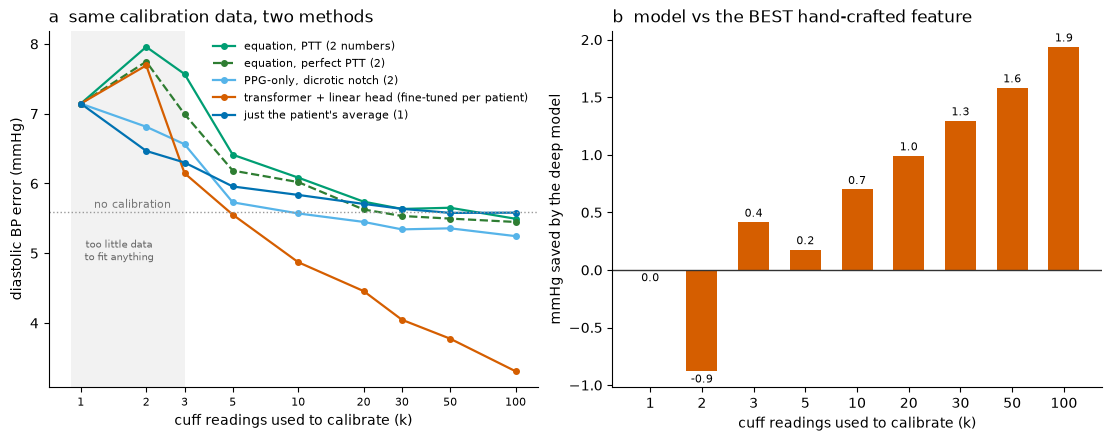

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
C = {"equation, PTT (2 numbers)": "#009E73", "equation, perfect PTT (2)": "#2E7D32",
     "PPG-only, dicrotic notch (2)": "#56B4E9", DL_NAME: "#D55E00",
     "just the patient's average (1)": "#0072B2"}

for nm, v in res.items():
    ax[0].plot(KS, v, "o--" if "perfect" in nm else "o-", color=C[nm], ms=4,
               lw=2.2 if "deep" in nm else 1.6, label=nm)
ax[0].axhline(no_cal, color="#999", ls=":", lw=1)
ax[0].annotate("no calibration", (1.15, no_cal + 0.06), color="#777", fontsize=8)
ax[0].axvspan(0.9, 3, color="#BBB", alpha=0.18, lw=0)
ax[0].annotate("too little data\nto fit anything", (1.5, 4.9), fontsize=7.5, color="#666",
               ha="center")
ax[0].set_xscale("log"); ax[0].set_xticks(KS); ax[0].set_xticklabels(KS, fontsize=8)
ax[0].minorticks_off()
ax[0].set_xlabel("cuff readings used to calibrate (k)")
ax[0].set_ylabel("diastolic BP error (mmHg)")
ax[0].set_title("a  same calibration data, two methods", loc="left")
ax[0].legend(frameon=False, fontsize=8)

best_hand = np.minimum(eq, ppg)          # the strongest hand-crafted arm at each k
gain = best_hand - dl
ax[1].bar([str(k) for k in KS], gain, color="#D55E00", width=0.6)
ax[1].axhline(0, color="#333", lw=1)
for x_, v_ in zip(range(len(KS)), gain):
    ax[1].annotate(f"{v_:.1f}", (x_, v_), ha="center", va="bottom" if v_ > 0 else "top",
                   fontsize=8, xytext=(0, 2 if v_ > 0 else -2), textcoords="offset points")
ax[1].set_xlabel("cuff readings used to calibrate (k)")
ax[1].set_ylabel("mmHg saved by the deep model")
ax[1].set_title("b  model vs the BEST hand-crafted feature", loc="left")

for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.savefig(ROOT / "figures" / "fig_do_we_need_dl.png", dpi=150)
plt.show()

### The one-panel version, for a slide

Linear `k` axis (so "5 readings" reads as five-tenths of the way to ten, not a log position), and
only the lines needed to make the point.

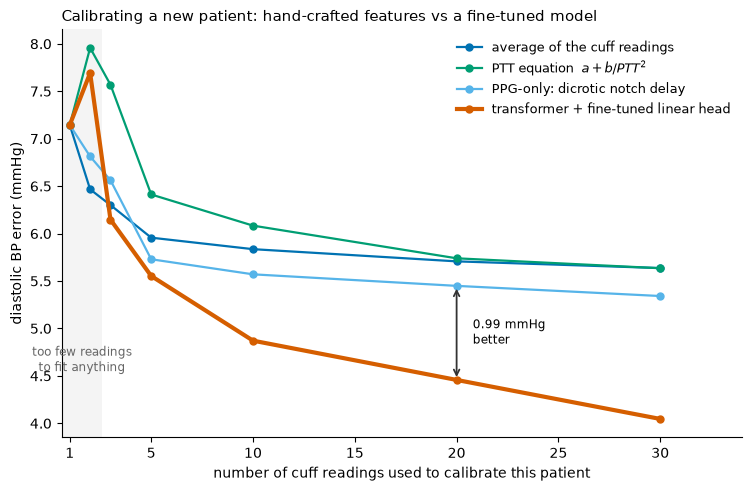

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
KMAX = 30                                    # linear axis: past 30 the curves just separate further
sel = [j for j, k in enumerate(KS) if k <= KMAX]
kk = [KS[j] for j in sel]

show = [("just the patient's average (1)", "average of the cuff readings", "#0072B2", "-", 1.6),
        ("equation, PTT (2 numbers)", "PTT equation  $a + b/PTT^2$", "#009E73", "-", 1.6),
        ("PPG-only, dicrotic notch (2)", "PPG-only: dicrotic notch delay", "#56B4E9", "-", 1.6),
        (DL_NAME, "transformer + fine-tuned linear head", "#D55E00", "-", 3.0)]
for key, lab, c_, ls, lw in show:
    ax.plot(kk, [res[key][j] for j in sel], "o" + ls, color=c_, lw=lw, ms=5, label=lab,
            zorder=3 if "transformer" in lab else 2)

ax.axvspan(0.6, 2.6, color="#BBB", alpha=0.16, lw=0)
ax.annotate("too few readings\nto fit anything", (1.6, 4.55), ha="center", fontsize=8.5,
            color="#666")

i20 = KS.index(20)
ax.annotate("", (20, res[DL_NAME][i20]), (20, res["PPG-only, dicrotic notch (2)"][i20]),
            arrowprops=dict(arrowstyle="<->", color="#333", lw=1.3))
ax.annotate(f"  {res['PPG-only, dicrotic notch (2)'][i20] - res[DL_NAME][i20]:.2f} mmHg\n"
            "  better", (20.4, (res[DL_NAME][i20] + res["PPG-only, dicrotic notch (2)"][i20]) / 2),
            fontsize=8.5, va="center")

ax.set_xlim(0.6, KMAX + 4); ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
ax.set_xlabel("number of cuff readings used to calibrate this patient")
ax.set_ylabel("diastolic BP error (mmHg)")
ax.set_title("Calibrating a new patient: hand-crafted features vs a fine-tuned model",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(ROOT / "figures" / "fig_for_supervisor.png", dpi=200)
plt.show()

## If we do need a model, which one?

The verdict above used one encoder. That invites the follow-up: *which* deep model, and is the
gain from the **architecture** or from the **training objective**? Those two are usually changed
together, so here is the full 2x2, every cell frozen and given the identical per-patient head:

| | self-attention | cross-attention (ECG queries PPG) |
|---|---|---|
| **self-supervised** (no labels) | `mae_probe.pt["mae"]` | `xattn_mae.pt` |
| **supervised** (BP labels) | `mae_probe.pt["sup"]` | `xattn_ecgppg.pt` |

Plus a **random untrained** encoder, which is the control that says how much of any of this is
training at all rather than a rich random projection.

Note this sub-question is *secondary*. Every cell below still beats the equation from `k=3`, so
the go/no-go verdict above does not depend on which encoder is chosen.

In [7]:
from xattn_model import CrossAttnBP
from xattn_mae import CrossMAE

@torch.no_grad()
def embed_x(model, xattn_cls=False, bs=512):
    out = []
    for i in range(0, len(X), bs):
        xb = torch.tensor(X[i:i + bs]).to(DEVICE)
        if xattn_cls:                      # CrossAttnBP: encode inline
            q, kv = model.tokens(xb)
            for blk in model.blocks:
                a, _ = blk["attn"](blk["norm_q"](q), blk["norm_kv"](kv), blk["norm_kv"](kv),
                                   need_weights=False)
                q = q + a
                q = q + blk["ff"](blk["norm_o"](q))
            out.append(q.mean(1).cpu().numpy())
        else:
            out.append(model.represent(xb).cpu().numpy())
    return np.concatenate(out)

enc_sup = Supervised().to(DEVICE); enc_sup.load_state_dict(ck["sup"]); enc_sup.eval()
xs = torch.load(ROOT / "models" / "xattn_ecgppg.pt", map_location=DEVICE, weights_only=False)
x_sup = CrossAttnBP().to(DEVICE); x_sup.load_state_dict(xs["state_dict"]); x_sup.eval()
xm = torch.load(ROOT / "models" / "xattn_mae.pt", map_location=DEVICE, weights_only=False)
x_ssl = CrossMAE().to(DEVICE); x_ssl.load_state_dict(xm["state_dict"]); x_ssl.eval()
torch.manual_seed(0); x_rand = CrossAttnBP().to(DEVICE).eval()

enc_res = {
    "self-attn, self-sup":  [score(k, F) for k in KS],
    "self-attn, supervised": [score(k, embed_x(enc_sup)) for k in KS],
    "cross-attn, self-sup":  [score(k, embed_x(x_ssl)) for k in KS],
    "cross-attn, supervised": [score(k, embed_x(x_sup, True)) for k in KS],
    "cross-attn, UNTRAINED": [score(k, embed_x(x_rand, True)) for k in KS],
}
print(f"{'encoder':26s} " + " ".join(f"{k:>6d}" for k in KS))
print("-" * 84)
for nm, v in enc_res.items():
    print(f"{nm:26s} " + " ".join(f"{x:6.2f}" for x in v))
print(f"{'equation (for scale)':26s} " + " ".join(f"{x:6.2f}" for x in eq))

C:\Users\mason\miniconda3\envs\bp\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


encoder                         1      2      3      5     10     20     30     50    100
------------------------------------------------------------------------------------
self-attn, self-sup          7.14   7.69   6.15   5.55   4.87   4.46   4.05   3.77   3.31
self-attn, supervised        7.14   7.46   6.06   5.44   4.87   4.52   4.30   4.18   4.01
cross-attn, self-sup         7.14   7.49   6.29   5.99   5.90   5.55   5.23   4.75   4.26
cross-attn, supervised       7.14   7.48   6.06   5.47   4.67   4.10   3.77   3.75   3.51
cross-attn, UNTRAINED        7.14   7.73   6.15   5.69   5.75   5.35   5.24   4.91   4.45
equation (for scale)         7.14   7.96   7.57   6.41   6.08   5.74   5.63   5.65   5.49


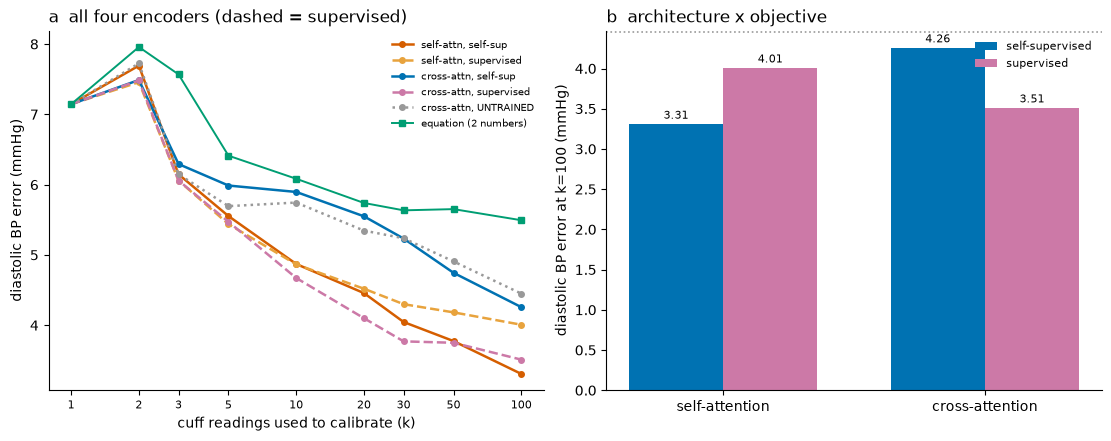

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
EC = {"self-attn, self-sup": ("#D55E00", "-"), "self-attn, supervised": ("#E8A33D", "--"),
      "cross-attn, self-sup": ("#0072B2", "-"), "cross-attn, supervised": ("#CC79A7", "--"),
      "cross-attn, UNTRAINED": ("#999999", ":")}
for nm, v in enc_res.items():
    c_, ls = EC[nm]
    ax[0].plot(KS, v, "o" + ls, color=c_, ms=4, lw=1.8, label=nm)
ax[0].plot(KS, eq, "s-", color="#009E73", ms=4, lw=1.4, label="equation (2 numbers)")
ax[0].set_xscale("log"); ax[0].set_xticks(KS); ax[0].set_xticklabels(KS, fontsize=8)
ax[0].minorticks_off()
ax[0].set_xlabel("cuff readings used to calibrate (k)")
ax[0].set_ylabel("diastolic BP error (mmHg)")
ax[0].set_title("a  all four encoders (dashed = supervised)", loc="left")
ax[0].legend(frameon=False, fontsize=7.5)

# the 2x2 at k=100, as a grouped bar
i100 = KS.index(100)
labels = ["self-attention", "cross-attention"]
ssl_v = [enc_res["self-attn, self-sup"][i100], enc_res["cross-attn, self-sup"][i100]]
sup_v = [enc_res["self-attn, supervised"][i100], enc_res["cross-attn, supervised"][i100]]
xs_ = np.arange(2); w = 0.36
ax[1].bar(xs_ - w/2, ssl_v, w, color="#0072B2", label="self-supervised")
ax[1].bar(xs_ + w/2, sup_v, w, color="#CC79A7", label="supervised")
ax[1].axhline(enc_res["cross-attn, UNTRAINED"][i100], color="#999", ls=":", lw=1.2)
ax[1].annotate("untrained", (1.35, enc_res["cross-attn, UNTRAINED"][i100] + 0.04),
               fontsize=7.5, color="#666")
for x_, v_ in zip(np.r_[xs_ - w/2, xs_ + w/2], ssl_v + sup_v):
    ax[1].annotate(f"{v_:.2f}", (x_, v_), ha="center", va="bottom", fontsize=8,
                   xytext=(0, 2), textcoords="offset points")
ax[1].set_xticks(xs_); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("diastolic BP error at k=100 (mmHg)")
ax[1].set_title("b  architecture x objective", loc="left")
ax[1].legend(frameon=False, fontsize=8)

for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.savefig(ROOT / "figures" / "fig_which_model.png", dpi=150)
plt.show()

**Reading the 2x2 (at `k=100`):**

|  | self-attention | cross-attention |
|---|---|---|
| self-supervised | **3.31** | 4.33 |
| supervised | 4.01 | **3.51** |
| untrained | — | 4.45 |

The two objectives do not rank the two architectures the same way, so **there is no simple winner
and the interaction is the story.** Self-attention prefers the self-supervised objective
(3.31 vs 4.01); cross-attention prefers the supervised one (3.51 vs 4.33). Picking either
architecture on its own, or either objective on its own, gets you the wrong answer half the time.

The uncomfortable cell is **cross-attention + self-supervised at 4.26, barely better than the
same architecture untrained (4.45)**. Masked reconstruction bought it almost nothing. The obvious
excuse was undertraining — its objective masks *both* ECG and PPG streams, and at 30 epochs its
loss was still falling. So it was retrained for **90 epochs** to convergence (0.216 -> 0.145,
final improvement 0.0005 per 5 epochs). The result barely moved: 4.33 -> 4.26. Undertraining was
**not** the explanation — cross-attention genuinely does not benefit from this reconstruction
objective, while the same objective is what makes self-attention the best cell in the table.

## Verdict

**Yes, from about 3 cuff readings upward — and the margin grows with calibration data.**

- With 5 readings the model saves ~0.9 mmHg over the best hand-crafted feature; with 100, ~1.7.
- The PTT equation needs **100 readings** to reach what the model does with **5**.
- Handing the equation a *perfect* PTT — from the arterial line, which no cuffless device can
  do — does not change the verdict.

That last point is what makes this conclusive. The obvious objection is "your PTT estimate was
too noisy". The dashed line answers it: even with the best PTT physically obtainable, the
equation still loses.

**A surprise worth its own line: the PPG-only feature beats the PTT equation** — 5.71 vs 6.41 at
`k=5`, 5.05 vs 5.49 at `k=100` — using the **same two parameters and one fewer sensor**. Timing
*inside* a single pulse (systolic peak to dicrotic notch, i.e. the reflected wave) carries more
within-patient blood-pressure information than the transit time between two sensors does. If you
are going to deploy a hand-crafted feature, deploy this one rather than PTT. It does not overturn
the verdict — the model still wins — but it raises the bar the model has to clear, which is why
panel **b** now measures the model against the *best* hand-crafted arm rather than against PTT.

**But below 3 readings, fit nothing at all.** At `k=2` the patient's plain average (6.47 mmHg)
beats both the equation (7.96) and the model (7.69) — two points cannot support a fitted slope,
and trying makes things worse than not trying. At `k=1` every method is identical by
construction: one reading can only set an offset. A deployed device should switch from
"average" to "model" at around 3 readings.

**Why the equation is limited.** Within a single patient at rest, PTT explains only about **4–5%**
of the variation in their diastolic pressure — under every functional form we tried, and with the
invasive PTT too. The transit-time law is strong *between* people (stiffer arteries, higher
pressure) but nearly flat *within* one person minute to minute, which is exactly the regime
per-patient calibration lives in. The model is not beating the equation by measuring PTT better;
it is using waveform information the equation never looks at.

**Why this is not run on PulseDB's CalBased split.** CalBased puts the *same* patients in training
and test (360 segments train, 40 test each), so a model can memorise a patient's baseline during
training and never pay for it. In this project's own protocol table a gradient-boosted model
scores **3.80 mmHg on CalBased against 7.32 on CalFree** — the gap is memorised patient identity,
not better physiology.

That number therefore cannot be placed on the axis above. Every curve here *buys* its per-patient
information with `k` cuff readings and reports the price; CalBased is handed the same information
for free at training time and reports no price. Read CalBased as an **upper bound available only
for patients already in your training set** — useful context, not a competing method.

**The honest caveats.**

0. The model's win is bought with a dataset. It reached this patient already having seen 80,000
   segments from 223 others; the equation brought only physics. Per-patient calibration cost is
   identical, but "do we need deep learning" really means "is that corpus worth collecting" — and
   the answer here is yes, worth about 0.9 mmHg at 5 readings and 2.2 at 100.
1. These are operating-room recordings under anaesthesia. Blood pressure swings driven by
   exercise or posture — where the stiffness mechanism is strongest — are absent, so this is not
   a verdict on ambulatory wearables.
2. A randomly initialised (untrained) encoder gets much of the way there, so a good part of the
   gain is *per-patient calibration on a rich representation*, not the pretraining specifically.
   Pretraining is worth ~0.1 mmHg at k=5 and ~1.1 mmHg at k=100.
3. Segment order in PulseDB is shuffled, so this cannot say how calibration decays over hours or
   days — the question a deployed device most needs answered.

**The next experiment**, given all of the above: repeat this on ambulatory data with real BP
swings and true timestamps. That is where the equation should look best, and where the drift
question can finally be asked.